In [4]:
import numpy as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df=pd.read_csv('IPL.csv')

In [5]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


### Basic information

In [10]:
#check the size of table rows and columns
print(f"your rows are{df.shape[0]} and your columns are {df.shape[1]} ")

your rows are74 and your columns are 20 


In [11]:
#to know how many columns have null value
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [13]:
#Whcih team won most matches

match_wins=df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 0, 'number of wins')

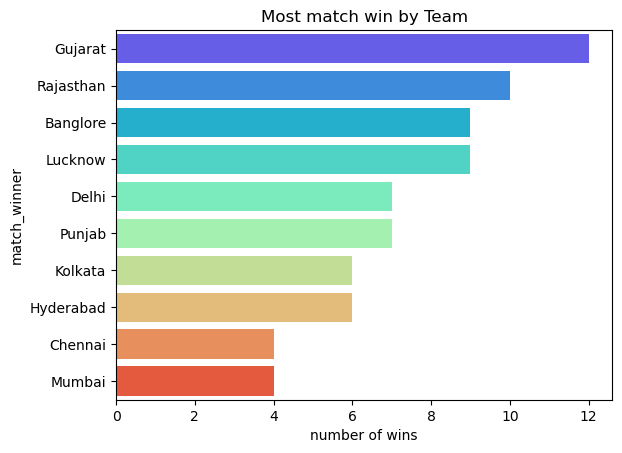

In [18]:
#to make bar graph for this data
sns.barplot(y=match_wins.index,x=match_wins.values)##overlappin
#for color change
sns.barplot(y=match_wins.index,x=match_wins.values,palette='rainbow')
#for title
plt.title("Most match win by Team")
plt.xlabel("number of wins")

<Axes: xlabel='toss_decision', ylabel='count'>

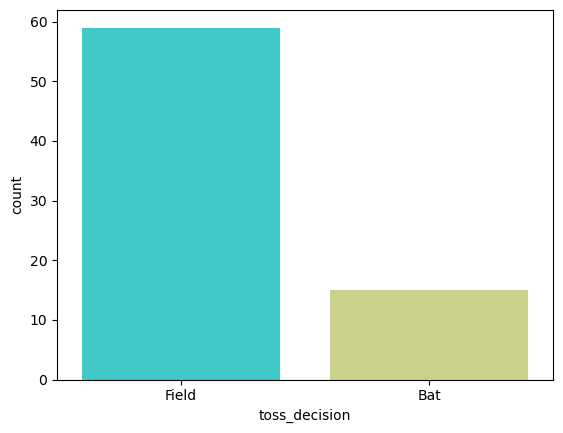

In [21]:
# toss decision trends
sns.countplot(x=df['toss_decision'],palette="rainbow")

### Toss winners vs Match Winner

In [26]:

df[df['toss_winner'] ==df['match_winner']].count()

match_id               36
date                   36
venue                  36
team1                  36
team2                  36
stage                  36
toss_winner            36
toss_decision          36
first_ings_score       36
first_ings_wkts        36
second_ings_score      36
second_ings_wkts       36
match_winner           36
won_by                 36
margin                 36
player_of_the_match    36
top_scorer             36
highscore              36
best_bowling           36
best_bowling_figure    36
dtype: int64

In [31]:
#to take out percentage of that
count=df[df['toss_winner'] ==df['match_winner']].count()
percentage=(count*100)/df.shape[0]
percentage.round(2) ##for after decimal kitne value rhenge

match_id               48.65
date                   48.65
venue                  48.65
team1                  48.65
team2                  48.65
stage                  48.65
toss_winner            48.65
toss_decision          48.65
first_ings_score       48.65
first_ings_wkts        48.65
second_ings_score      48.65
second_ings_wkts       48.65
match_winner           48.65
won_by                 48.65
margin                 48.65
player_of_the_match    48.65
top_scorer             48.65
highscore              48.65
best_bowling           48.65
best_bowling_figure    48.65
dtype: float64

### how many team wins by wickets or by runs

Text(0.5, 1.0, 'won by ')

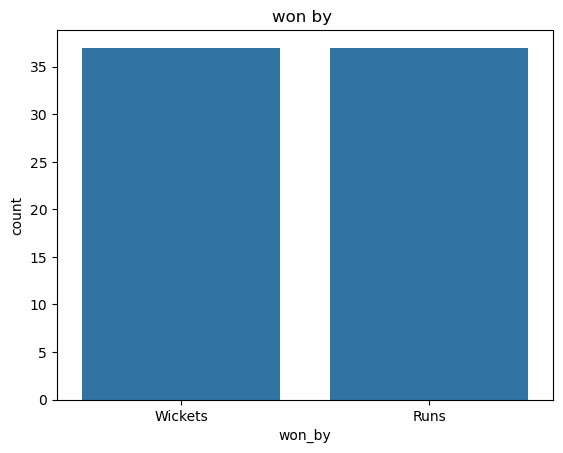

In [33]:
sns.countplot(x=df['won_by'])
plt.title("won by ")

### Player of the match

In [39]:
# it is provided columns in the table
#1 most player of the mathc
count=df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav      4
Jos Buttler        3
Umesh Yadav        2
Quinton de Kock    2
David Miller       2
Umran Malik        2
K L Rahul          2
Rahul Tripathi     2
Hardik Pandya      2
Jasprit Bumrah     2
Name: count, dtype: int64

<Axes: ylabel='player_of_the_match'>

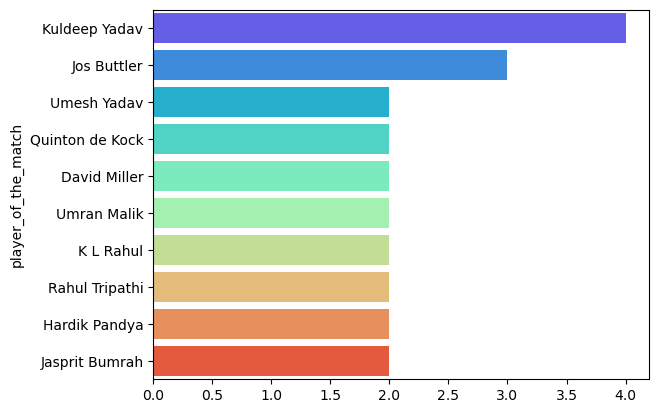

In [42]:
#for bart plot
sns.barplot(x=count.values,y=count.index,palette='rainbow')

### 2 top scoreres

In [49]:
#here we need to work more than one column we use

high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

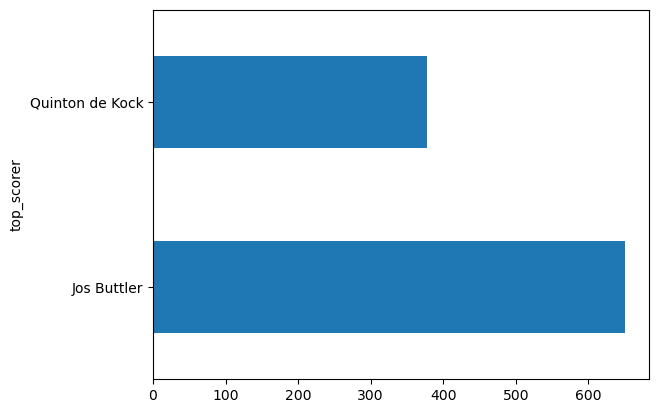

In [51]:
high.plot(kind="barh")

### 10 best Bowling figures

In [61]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df.head()
df['highest_wickets']=df['highest_wickets'].astype(int)
top_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False)
top_bowlers.head()

best_bowling
Yuzvendra Chahal    17
Kuldeep Yadav       11
Rashid Khan         11
Jasprit Bumrah      11
Avesh Khan          10
Name: highest_wickets, dtype: int64

<Axes: ylabel='best_bowling'>

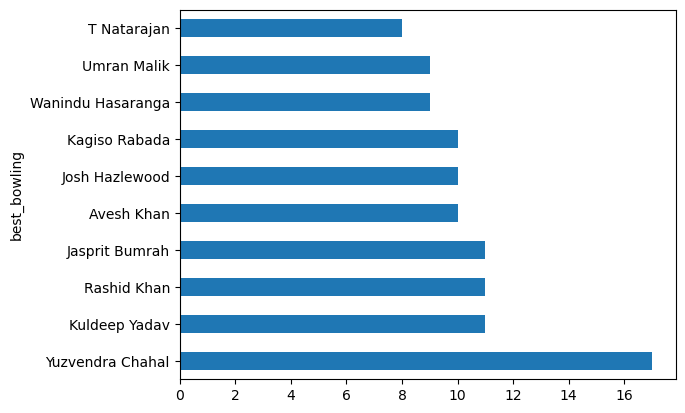

In [65]:
top_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='barh')

## Venue 

In [66]:
### most match played by value
venue_count=df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

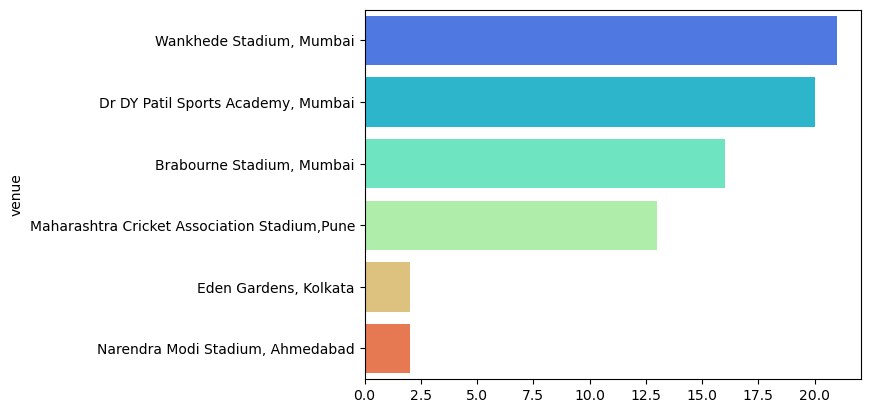

In [72]:
sns.barplot(y=venue_count.index,x=venue_count.values, palette='rainbow')

## custom made question


### who won the highest margin by run

In [78]:
df[df['won_by']=='Runs'].sort_values(by='margin' ,ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


### Which playet highest individual score

In [79]:
df[df['highscore'] ==df['highscore'].max()][['top_scorer']]

,top_scorer
65,Quinton de Kock


### wwhich bowler has the best bowling figure

In [83]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
